In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from scipy.integrate import solve_ivp
from scipy.special import kn
from scipy.integrate import cumulative_trapezoid
import pandas as pd

In [3]:
Mp = 2.435e18
rho_phi_0 = 1e60
rho_R_0 = 0.0

m_phi = 3e13
y_phi = 1e-5

Gamma = (y_phi**2 / (8 * np.pi)) * m_phi

In [4]:
def reheating_system(N, y):
  rho_phi, rho_R = y

  rho_phi_val = max(rho_phi, 1e-100)
  rho_R_val = max(rho_R, 1e-100)

  H = np.sqrt((rho_phi_val + rho_R_val) / (3 * Mp**2))


  drho_phi_dN = -3 * rho_phi - (Gamma / H) * rho_phi

  drho_R_dN = -4 * rho_R + (Gamma / H) * rho_phi

  return [drho_phi_dN, drho_R_dN]


N_start = 0
N_end = 15 * np.log(10)
N_eval = np.linspace(N_start, N_end, 5000)

sol = solve_ivp(
    reheating_system,
    [N_start, N_end],
    [rho_phi_0, rho_R_0],
    t_eval=N_eval,
    method='Radau',
    rtol=1e-10,
    atol=1e-10
)



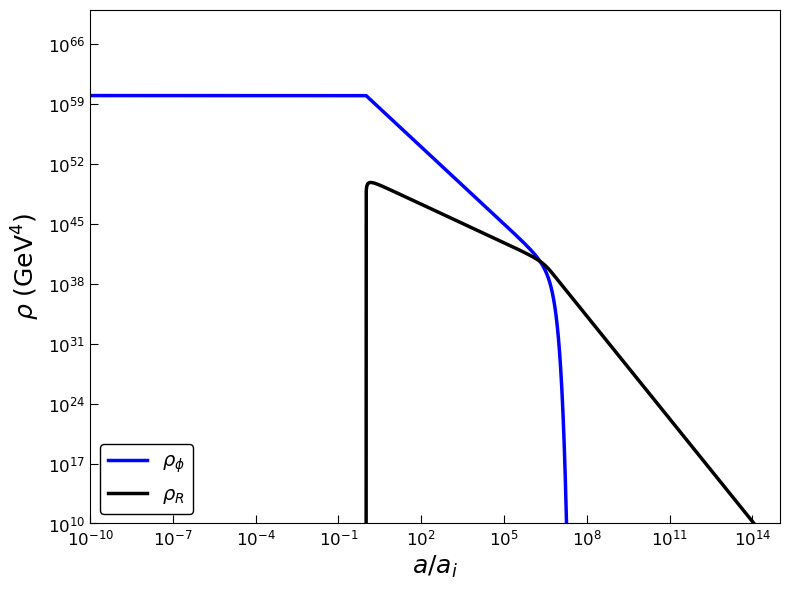

In [5]:
a_ratio_reheating = np.exp(sol.t)
rho_phi_reheating = sol.y[0]
rho_R_reheating = sol.y[1]


a_ratio_inflation = np.logspace(-10, 0, 100)
rho_phi_inflation = np.full_like(a_ratio_inflation, rho_phi_0)
rho_R_inflation = np.full_like(a_ratio_inflation, 1e-20)

a_ratio = np.concatenate((a_ratio_inflation, a_ratio_reheating))
rho_phi = np.concatenate((rho_phi_inflation, rho_phi_reheating))
rho_R = np.concatenate((rho_R_inflation, rho_R_reheating))

mask_phi = rho_phi > 0
mask_R = rho_R > 0

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(a_ratio[mask_phi], rho_phi[mask_phi], color='blue', lw=2.5, label=r'$\rho_\phi$')
ax.plot(a_ratio[mask_R], rho_R[mask_R], color='black', lw=2.5, label=r'$\rho_R$')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(1e-10, 1e15)
ax.set_ylim(1e10, 1e70)

ax.set_xlabel(r'$a/a_i$', fontsize=18, fontweight='bold')
ax.set_ylabel(r'$\rho$ (GeV$^4$)', fontsize=18)
ax.tick_params(axis='both', which='major', labelsize=12, direction='in', length=6)
ax.legend(loc='lower left', fontsize=14, framealpha=1.0, edgecolor='black')

plt.tight_layout()
plt.show()